
<h1 align=center> Protokoll H1 </h1>
<h4 align=center> Gruppe 8 </h4>
<h3 align=center> Fynn Kanja 3780065, Valentino D’Agosto 3763229 </h3>
<h4 align=center> 11.04.2025 </h4>

# Inhaltsverzeichnis
[1. Motivation](#1.-Motivation)<br>
[1.1 Aufgabenstellung](#1.1-Aufgabenstellung)<br>
[2. Aufgabe 1: Messung der Beschleunigungs- und Gyroskopdaten](#2.-Aufgabe-1%3A-Messung-der-Beschleunigungs--und-Gyroskopdaten)<br>
[3. Bestimmung der Pendelfrequenz](#3.-Bestimmung-der-Pendelfrequenz)<br>
&emsp;[3.1 Auswertung der linearen Beschleunigung](#3.1-Auswertung-der-linearen-Beschleunigung)<br>
&emsp;[3.2 Bestimmung der Pendelfrequenz mittels Curve Fitting](#3.2-Bestimmung-der-Pendelfrequenz-mittels-Curve-Fitting)<br>
&emsp;[3.3 Aus den Gyroskopdaten ermitteln](#3.3-Aus-den-Gyroskopdaten-ermitteln)<br>
&emsp;[3.5 Berechnung der Pendelfrequenz](#3.5-Berechnung-der-Pendelfrequenz)<br>
&emsp;[4. Bestimmung der Dämpfungskonstante](#4.-Bestimmung-der-D%C3%A4mpfungskonstante)<br>
[5. Bestimmung der Komponenten der Beschleunigung](#5.-Bestimmung-der-Komponenten-der-Beschleunigung)<br>
[6. Fazit](#6.-Fazit)<br>

# 1. Motivation
Ziel dieses Versuchs ist es, die Frequenz, Dämpfungskonstante sowie die Beschleunigungskomponenten des selber gebauten Smartphone-Pendels experimentell zu bestimmen. Des Weiteren werden mithilfe der theoretischen Grundlagen Erwartungswerte berechnet und diese mit den experimentell bestimmten Werten verglichen. Das Experiment selber wurde mehrfach durchgeführt und die Werte des am besten gelungenen Versuchs werden für das Protokoll genutzt.

# 1.1 Aufgabenstellung
1. Verwenden Sie Ihr Smartphone als Pendelkörper und messen Sie simultan die Winkelgeschwindigkeit (Drehrate), die Beschleunigung, und die lineare Beschleunigung (Beschleunigung ohne g ) ihres Smartphones während des Pendelvorgangs.
    
2. Bestimmen Sie die Pendelfrequenz mit drei unterschiedlichen Methoden. Berechnen Sie den theoretischen Wert. Liegt dieser noch innerhalb der Messabweichung?
    
3. Bestimmen Sie die Dämpfungskonstante.
    
4. Berechnen Sie die Komponenten der Beschleunigung unter Verwendung der gemessenen Drehrate und vergleichen Sie mit der gemessenen Beschleunigungswerten (mit und ohne g ). Stellen Sie dazu die gemessenen und die berechneten Beschleunigungskomponenten in jeweils einem Diagramm dar.

# 2. Aufgabe 1: Messung der Beschleunigungs- und Gyroskopdaten
Für die Messung der Daten wurde ein Handy mit der Phyphox App genutzt. Mithilfe der App kann man die Rohdaten aus den verschiedensten Sensoren auslesen, die in einem Smartphone verbaut sind. Während des Experiments wurden Beschleunigung, lineare Beschleunigung mit dem Beschleunigungssensor und Winkelgeschwindigkeit mithilfe des Gyroskopsensors auf allen drei Achsen gleichzeitig gemessen.

Der Aufbau des Experiments bestand, wie in Abbildung [1](#eq1) zu sehen, aus einem Smartphone, welches an zwei parallelen Fäden, wie bei einer Schaukel, um die Rotation während des Pendels zu minimieren, an einem Regenschirm befestigt wurde. Dabei zeigte die Handyoberfläche parallel zum Boden den Einfluss des Luftwiderstandes zu minimieren. Somit befindet sich die positive z-Achse in Richtung Boden, die positive y-Achse zeigt nach links und die positive x-Achse zur Richtung der Kamera. Die gesamte Pendellänge mit Handyhülle und Fadenlänge betrug 93 cm, wobei die Fäden 92 cm lang waren.

Bei Beginn der Messung befand sich das System in der Ruhelage und wurde erst danach ausgelenkt, damit das Gyroskop kalibriert war und den Wert 0 in der Ruhelage anzeigt. Beim Auslenken wurde nur um einen kleinen Winkel ausgelenkt, damit man das Pendel vereinfacht als mathematisches Pendel betrachten kann, da die Kleinwinkelnäherung angewendet werden kann. Beim Loslassen wurde versucht, dem Smartphone möglichst wenig Drehung und Schwung mitzugeben, sodass sich das Handy beim Pendeln nicht dreht oder die Messwerte verfälscht. Zur Minimierung möglicher Messfehler wurde das Pendel zunächst für 20 Sekunden eingeschwungen, um möglichst reine Messdaten zu erhalten.

Während des insgesamt 143 Sekunden andauernden Versuchs wurden Messdaten aufgezeichnet, die anschließend analysiert wurden, die in der folgenden Tabelle präsentiert wrden.



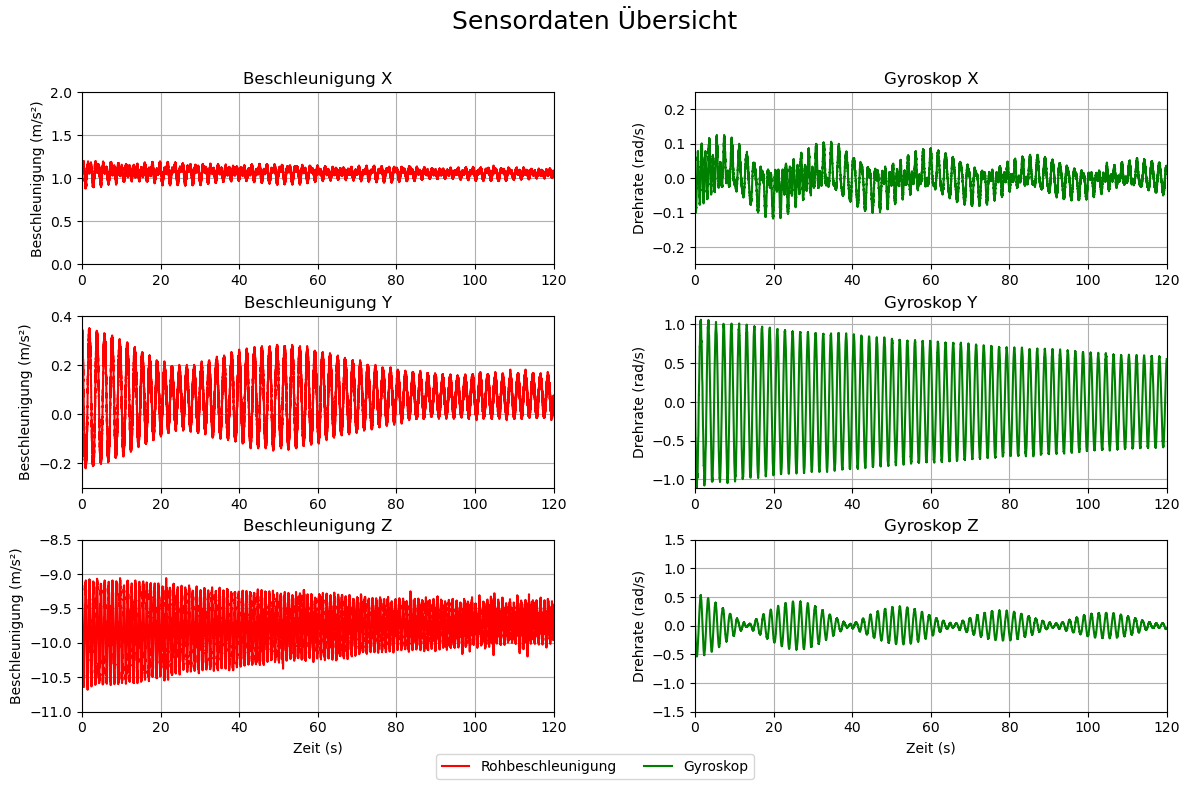

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gemeinsame Einstellungen
end_time = 120
start_time = 20.3

# 3x2 Subplot erstellen
fig, axs = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle('Sensordaten Übersicht', fontsize=18)

# Beschleunigungsdaten (Spalte 1)
df_acc = pd.read_csv('data/Accelerometer.csv')
df_acc['Zeit_Angepasst'] = df_acc['Time (s)'] - start_time

axs[0, 0].plot(df_acc['Zeit_Angepasst'], df_acc['Acceleration x (m/s^2)'], color='r')
axs[0, 0].set_title('Beschleunigung X')
axs[0, 0].set_ylabel('Beschleunigung (m/s²)')
axs[0, 0].set_xlim(0, end_time)
axs[0, 0].set_ylim(0, 2)
axs[0, 0].grid(True)

axs[1, 0].plot(df_acc['Zeit_Angepasst'], df_acc['Acceleration y (m/s^2)'], color='r')
axs[1, 0].set_title('Beschleunigung Y')
axs[1, 0].set_ylabel('Beschleunigung (m/s²)')
axs[1, 0].set_xlim(0, end_time)
axs[1, 0].set_ylim(-0.3, 0.4)
axs[1, 0].grid(True)

axs[2, 0].plot(df_acc['Zeit_Angepasst'], df_acc['Acceleration z (m/s^2)'], color='r')
axs[2, 0].set_title('Beschleunigung Z')
axs[2, 0].set_ylabel('Beschleunigung (m/s²)')
axs[2, 0].set_xlabel('Zeit (s)')
axs[2, 0].set_xlim(0, end_time)
axs[2, 0].set_ylim(-11, -8.5)
axs[2, 0].grid(True)

# Gyroskop-Daten (Spalte 2)
df_gyro = pd.read_csv('data/Gyroscope.csv')
df_gyro['Zeit_Angepasst'] = df_gyro['Time (s)'] - start_time

axs[0, 1].plot(df_gyro['Zeit_Angepasst'], df_gyro['Gyroscope x (rad/s)'], color='g')
axs[0, 1].set_title('Gyroskop X')
axs[0, 1].set_ylabel('Drehrate (rad/s)')
axs[0, 1].set_xlim(0, end_time)
axs[0, 1].set_ylim(-0.25, 0.25)
axs[0, 1].grid(True)

axs[1, 1].plot(df_gyro['Zeit_Angepasst'], df_gyro['Gyroscope y (rad/s)'], color='g')
axs[1, 1].set_title('Gyroskop Y')
axs[1, 1].set_ylabel('Drehrate (rad/s)')
axs[1, 1].set_xlim(0, end_time)
axs[1, 1].set_ylim(-1.11, 1.11)
axs[1, 1].grid(True)

axs[2, 1].plot(df_gyro['Zeit_Angepasst'], df_gyro['Gyroscope z (rad/s)'], color='g')
axs[2, 1].set_title('Gyroskop Z')
axs[2, 1].set_ylabel('Drehrate (rad/s)')
axs[2, 1].set_xlabel('Zeit (s)')
axs[2, 1].set_xlim(0, end_time)
axs[2, 1].set_ylim(-1.5, 1.5)
axs[2, 1].grid(True)

# Lineare Beschleunigungsdaten (Spalte 3)
#df_lin = pd.read_csv('data/Linear Acceleration.csv')
#df_lin['Zeit_Angepasst'] = df_lin['Time (s)'] - start_time

#axs[0, 2].plot(df_lin['Zeit_Angepasst'], df_lin['Linear Acceleration x (m/s^2)'], color='b')
#axs[0, 2].set_title('Lineare Beschleunigung X')
#axs[0, 2].set_ylabel('Lin. Beschl. (m/s²)')
#axs[0, 2].set_xlim(0, end_time)
#axs[0, 2].set_ylim(-2.8, 2.8)
#axs[0, 2].grid(True)

#axs[1, 2].plot(df_lin['Zeit_Angepasst'], df_lin['Linear Acceleration y (m/s^2)'], color='b')
#axs[1, 2].set_title('Lineare Beschleunigung Y')
#axs[1, 2].set_ylabel('Lin. Beschl. (m/s²)')
#axs[1, 2].set_xlim(0, end_time)
#axs[1, 2].set_ylim(-2, 2)
#axs[1, 2].grid(True)

#axs[2, 2].plot(df_lin['Zeit_Angepasst'], df_lin['Linear Acceleration z (m/s^2)'], color='b')
#axs[2, 2].set_title('Lineare Beschleunigung Z')
#axs[2, 2].set_ylabel('Lin. Beschl. (m/s²)')
#axs[2, 2].set_xlabel('Zeit (s)')
#axs[2, 2].set_xlim(0, end_time)
#axs[2, 2].set_ylim(-1.5, 1.5)
#axs[2, 2].grid(True)

# Legende für die gesamten Spalten erstellen
handles = [
    plt.Line2D([0], [0], color='r', label='Beschleunigung'),
    plt.Line2D([0], [0], color='g', label='Drehrate'),
    #plt.Line2D([0], [0], color='b', label='Lineare Beschleunigung')
]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # Anpassung für die Legende unten
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Abstand zwischen den Subplots erhöhen
plt.show()

<img src="figures/Versuchsaufbau_H1.jpg" alt="Abbildung 1: Aufbau des Pendelversuchs" width="500" height="600" style="vertical-align:middle" id="aufbau" />
<p align=center> Abbildung 1: Aufbau des Pendelversuchs </p>
</a name="eq1">

# 3. Bestimmung der Pendelfrequenz

## 3.1 Auswertung der linearen Beschleunigung
Um die Frequenz des Pendels zu bestimmen, analysieren wir die Zeitpunkte der Beschleunigungsmaxima, die im obersten Diagramm hervorgehoben sind. Die ermittelten Spitzen treten bei den Zeitpunkten $ t = 0,8\text{s} $, $ t = 2,73\text{s} $, $ t = 4,7\text{s} $, $ t = 6,64\text{s} $ und $ t = 8,6\text{s} $ auf. 

Die Periodendauer $ T $ zwischen zwei aufeinanderfolgenden Peaks lässt sich durch die Differenz der entsprechenden Zeitpunkte berechnen:
$T = t_{i+1} - t_i$
Die Frequenz $ f $ des Pendels ergibt sich schließlich als Kehrwert der Periodendauer:
$f = \frac{1}{T}$


| Periode | Zeit (s) | Periodendauer (s) | Frequenz (1/s) |
|:-------:|:--------:|:-----------------:|:--------------:|
| 0 | 0,8 | -- | -- |
| 1 | 2,75 | 1,95 | 0,513 |
| 2 | 4,7 | 1,95 | 0,513 |
| 3 | 6,64 | 1,94 | 0,515 |
| 4 | 8,6 | 1,96 | 0,510 |
| Durchschnitt | -- | 1,95 | 0,513 |


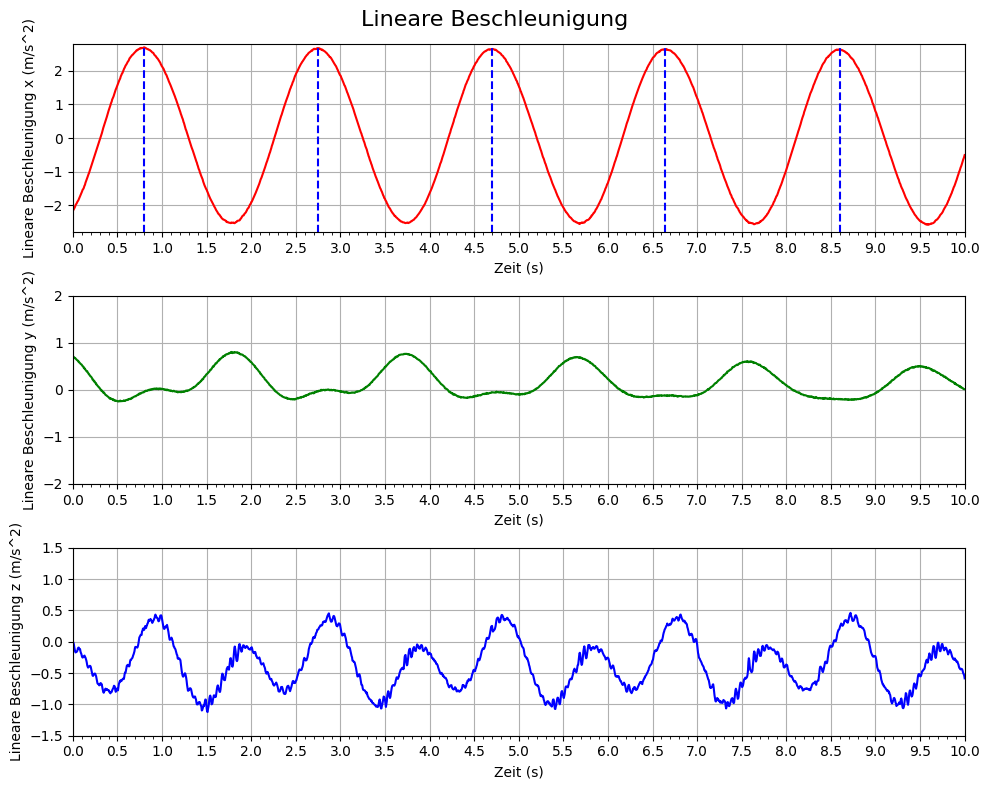

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

end_time = 10

# Read Linear Acceleration.csv file
df = pd.read_csv('data/Linear Acceleration.csv')

# Erstelle neue Zeitachse, die bei 0 beginnt (durch Subtraktion des Startwertes)
start_time = 20.3
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

# Plot mit der angepassten Zeitachse
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Lineare Beschleunigung', fontsize=16)

axs[0].plot(df['Zeit_Angepasst'], df['Linear Acceleration x (m/s^2)'], label='Lineare Beschleunigung x (m/s^2)', color='r')
axs[0].set_ylabel('Lineare Beschleunigung x (m/s^2)')
axs[0].set_xlabel('Zeit (s)')
axs[0].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten
axs[0].set_ylim(-2.8, 2.8)
axs[0].grid()
axs[0].xaxis.set_major_locator(plt.MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(plt.MultipleLocator(0.1))
axs[0].plot([0.8, 0.8], [4,-4], color='b' , linestyle='--')
axs[0].plot([2.75,2.75], [4,-4], color='b' , linestyle='--')
axs[0].plot([4.7,4.7], [4,-4], color='b' , linestyle='--')
axs[0].plot([6.64,6.64], [4,-4], color='b' , linestyle='--')
axs[0].plot([8.6,8.6], [4,-4], color='b' , linestyle='--')

axs[1].plot(df['Zeit_Angepasst'], df['Linear Acceleration y (m/s^2)'], label='Lineare Beschleunigung x (m/s^2)', color='g') # -0.04 damit der Graph besser aussieht.
axs[1].set_ylabel('Lineare Beschleunigung y (m/s^2)')
axs[1].set_xlabel('Zeit (s)')
axs[1].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten
axs[1].xaxis.set_major_locator(plt.MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(plt.MultipleLocator(0.1))
axs[1].set_ylim(-2, 2)
axs[1].grid()

axs[2].plot(df['Zeit_Angepasst'], df['Linear Acceleration z (m/s^2)'], label='Lineare Beschleunigung x (m/s^2)', color='b') # Warum auch immer hat er hier anscheinde doch g aufgenommen.
axs[2].set_ylabel('Lineare Beschleunigung z (m/s^2)')
axs[2].set_xlabel('Zeit (s)')
axs[2].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten 
axs[2].xaxis.set_major_locator(plt.MultipleLocator(0.5))
axs[2].xaxis.set_minor_locator(plt.MultipleLocator(0.1))
axs[2].set_ylim(-1.5, 1.5)
axs[2].grid()

# Berechne die Winkelbechleunigung
df['Winkelbeschleunigung x (rad/s^2)'] = np.gradient(df['Linear Acceleration x (m/s^2)'], df['Zeit_Angepasst'])
df['Winkelbeschleunigung y (rad/s^2)'] = np.gradient(df['Linear Acceleration y (m/s^2)'], df['Zeit_Angepasst'])
df['Winkelbeschleunigung z (rad/s^2)'] = np.gradient(df['Linear Acceleration z (m/s^2)'], df['Zeit_Angepasst'])



plt.tight_layout()
plt.show()

## 3.2 Bestimmung der Pendelfrequenz mittels Curve Fitting

Um die Frequenz des Pendels zu bestimmen, wurde eine Sinusfunktion an die Messdaten der Beschleunigung angepasst. Diese Methode eignet sich besonders gut, da das Signal durch periodische, schwingende Bewegungen geprägt ist – ein typisches Verhalten bei einem Pendel. Der Vorteil des Curve-Fittings gegenüber Methoden wie der Fourier-Analyse liegt darin, dass die Frequenz direkt als Parameter einer Sinusfunktion geschätzt wird und zusätzlich Informationen über Amplitude, Phase und Offset bereitgestellt werden.

Für die Auswertung wurde die y-Achse der Beschleunigungsdaten gewählt. Diese zeigt eine klare periodische Struktur mit einer gut ausgeprägten Sinusform, die für ein stabiles und zuverlässiges Fit-Ergebnis erforderlich ist. Im Vergleich dazu ist die x-Achse stark verrauscht und die z-Achse weist zwar Schwingungen auf, ist jedoch durch die konstante Gravitation stark negativ überlagert. Zudem war die y-Achse auch diejenige, auf der das Smartphone geschwungen ist.

Die Anpassung der Kurve an die y-Komponente ergab eine Frequenz von: $f_{freq}=0,513$ Hz, wie in der Abbildung \ref als gestrichelte Linie im zweiten Diagramm dargestellt ist

Fitted frequency: 0.513 Hz


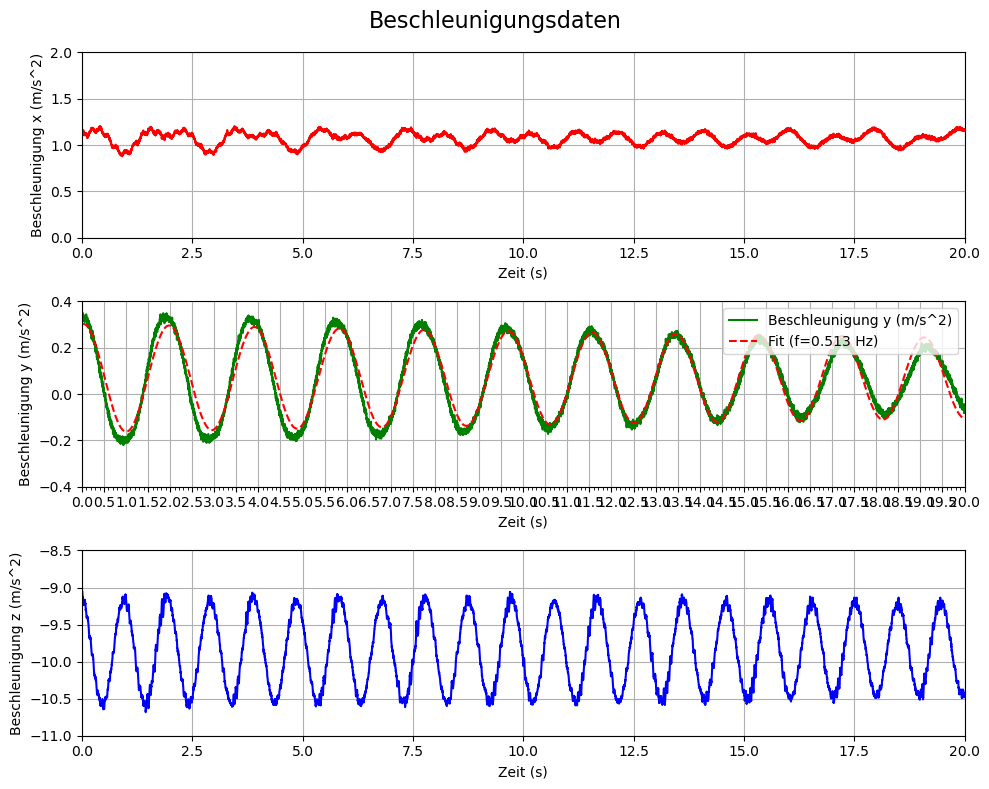

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.optimize

end_time = 20


# Read Accelerometer.csv file
df = pd.read_csv('data/Accelerometer.csv')



# Erstelle neue Zeitachse, die bei 0 beginnt (durch Subtraktion des Startwertes)
start_time = 20.3
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

# Plot mit der angepassten Zeitachse
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Beschleunigungsdaten', fontsize=16)

axs[0].plot(df['Zeit_Angepasst'], df['Acceleration x (m/s^2)'], label='Beschleunigung x (m/s^2)', color='r')
axs[0].set_ylabel('Beschleunigung x (m/s^2)')
axs[0].set_xlabel('Zeit (s)')
axs[0].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten
axs[0].set_ylim(0, 2)
axs[0].grid()

axs[1].plot(df['Zeit_Angepasst'], df['Acceleration y (m/s^2)'], label='Beschleunigung y (m/s^2)', color='g')
axs[1].set_ylabel('Beschleunigung y (m/s^2)')
axs[1].set_xlabel('Zeit (s)')
axs[1].set_xlim(0, end_time)  
axs[1].set_ylim(-0.4, 0.4)
axs[1].grid()

def sinfunc(t, A, w, p, g, _lambda, c2):  
    return A * np.exp(-_lambda*t) * np.sin(np.exp(-g*t)*w*t + p) + c2

# Initial parameters based on data analysis
# Somehow the curve will fit better if we add another damping constant
p0 = [
    0.4,          # A: amplitude
    2*np.pi*0.5,  # w: starting frequency
    0,            # p: phase shift
    0.002,         # g: damping constant for frequency
    0.04,         # lambda: damping constant for amplitude
    0,            # c2: vertical offset
]

mask = df['Zeit_Angepasst'] <= end_time
t_fit = df['Zeit_Angepasst'][mask]
y_fit = df['Acceleration y (m/s^2)'][mask] + 0.04

popt, pcov = scipy.optimize.curve_fit(sinfunc, t_fit, y_fit, p0=p0)
A, w, p, g, _lambda, c2 = popt
f = w/(2.*np.pi)
print(f"Erhaltene Frequenz: {f:.3f} Hz")
#print(f"Dämpfungskonstante: {g}") => -0.0011682543226750118
#print(f"Dämpfungskonstante: {_lambda}") => 0.01491478347667464

t_smooth = np.linspace(0, end_time, 1000)
fit_smooth = sinfunc(t_smooth, *popt)
axs[1].plot(t_smooth, fit_smooth, 'r--', label=f'Fit (f={f:.3f} Hz)')
axs[1].legend(loc='upper right')




axs[2].plot(df['Zeit_Angepasst'], df['Acceleration z (m/s^2)'], label='Beschleunigung z (m/s^2)', color='b')
axs[2].set_ylabel('Beschleunigung z (m/s^2)')
axs[2].set_xlabel('Zeit (s)')
axs[2].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten 
axs[2].set_ylim(-11, -8.5)
axs[2].grid()
axs[1].xaxis.set_major_locator(plt.MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(plt.MultipleLocator(0.1))


plt.tight_layout()
plt.show()

## 3.3 Aus den Gyroskopdaten ermitteln
Zur Bestimmung der Pendelfrequenz ist zunächst die relevante Komponente der Gyroskopdaten zu identifizieren. Aufgrund des Versuchsaufbaus, bei dem sich das Smartphone während der Schwingung primär um die y-Achse dreht, ist die Gyroskop-Komponente in y-Richtung maßgeblich.

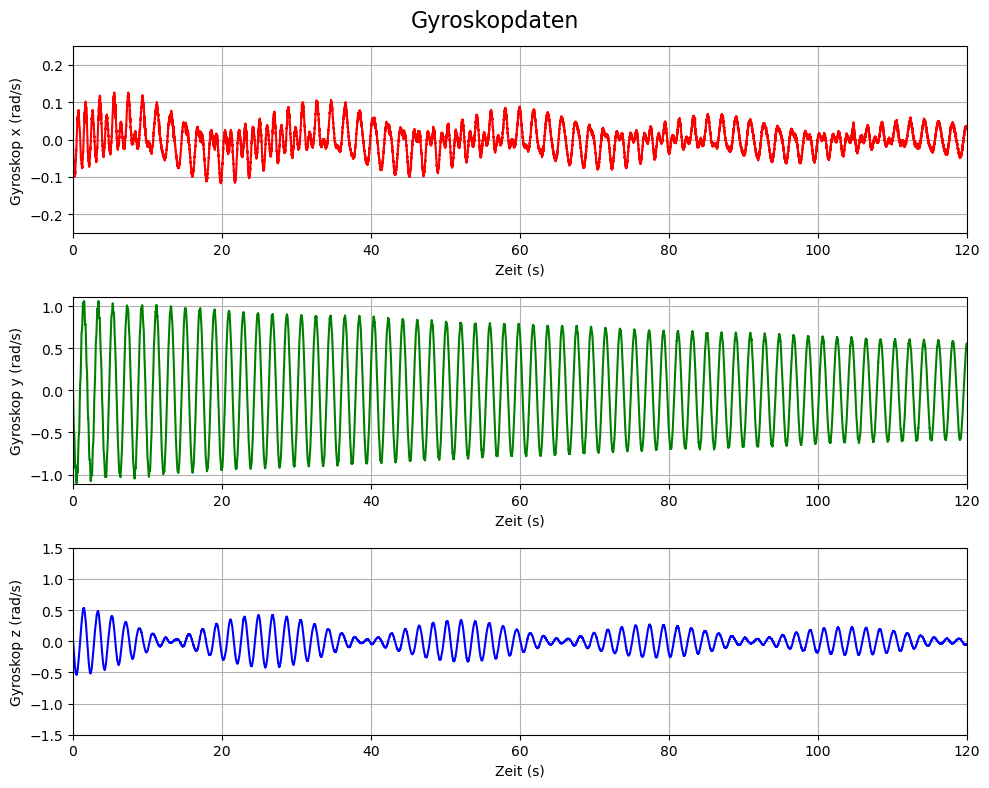

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

end_time = 120

# Read Gyroscope.csv file
df = pd.read_csv('data/Gyroscope.csv')

# Erstelle neue Zeitachse, die bei 0 beginnt (durch Subtraktion des Startwertes)
start_time = 20.3
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

# Plot mit der angepassten Zeitachse
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Gyroskopdaten', fontsize=16)

axs[0].plot(df['Zeit_Angepasst'], df['Gyroscope x (rad/s)'], label='Gyroskop x (rad/s)', color='r')
axs[0].set_ylabel('Gyroskop x (rad/s)')
axs[0].set_xlabel('Zeit (s)')
axs[0].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten
axs[0].set_ylim(-0.25, 0.25)
axs[0].grid()

axs[1].plot(df['Zeit_Angepasst'], df['Gyroscope y (rad/s)'], label='Gyroskop y (rad/s)', color='g') # -0.04 damit der Graph besser aussieht.
axs[1].set_ylabel('Gyroskop y (rad/s)')
axs[1].set_xlabel('Zeit (s)')
axs[1].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten
axs[1].set_ylim(-1.11, 1.11)
axs[1].grid()

axs[2].plot(df['Zeit_Angepasst'], df['Gyroscope z (rad/s)'], label='Gyroskop z (rad/s)', color='b') # Warum auch immer hat er hier anscheinde doch g aufgenommen.
axs[2].set_ylabel('Gyroskop z (rad/s)')
axs[2].set_xlabel('Zeit (s)')
axs[2].set_xlim(0, end_time)  # Entspricht 20.3 bis 50.3 in den Originaldaten 
axs[2].set_ylim(-1.5, 1.5)
axs[2].grid()


plt.tight_layout()
plt.show()

Aus dem Zeitdiagramm \ref{gyroskop} allein lässt sich die dominante Frequenz der sinusförmigen Bewegung jedoch nur schwer bestimmen. Daher wird zur Frequenzanalyse eine Fourier-Transformation durchgeführt.

Wie in Abbildung \ref{frequenzspektrum} ersichtlich, ergibt die Frequenzanalyse mittels Fourier-Transformation eine dominante Pendelfrequenz von $f_{gyro} = 0,516$ Hz.

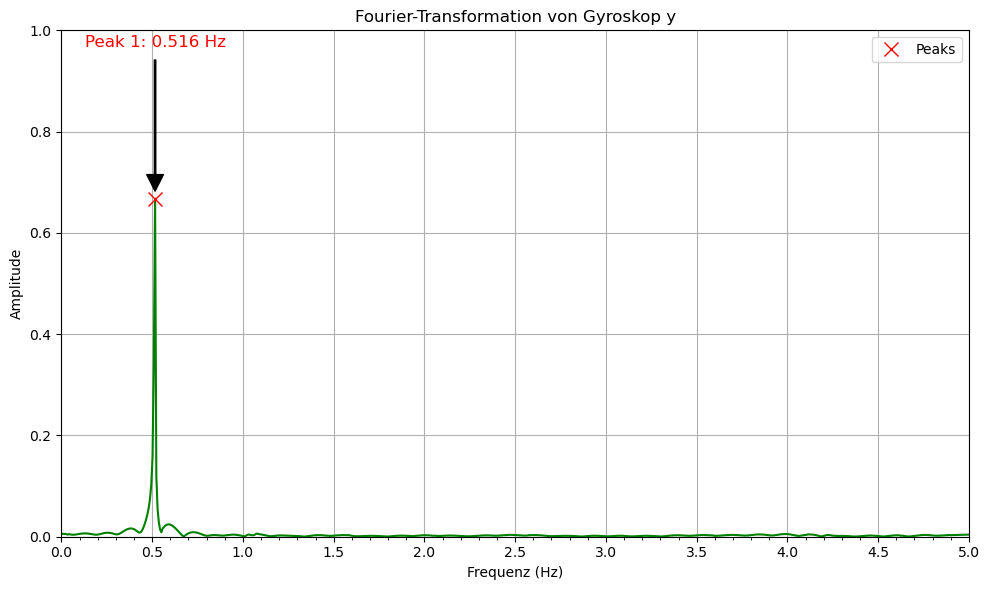

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# Read Gyroscope.csv file
df = pd.read_csv('data/Gyroscope.csv')

# Erstelle neue Zeitachse, die bei 0 beginnt
start_time = 20.3
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

# Konvertiere die pandas Series zu NumPy-Arrays für die FFT
gyro_data = df['Gyroscope y (rad/s)'].to_numpy()

# Berechnung der Fourier-Transformation
N = len(gyro_data)
T = df['Zeit_Angepasst'].iloc[1] - df['Zeit_Angepasst'].iloc[0]  # Zeitintervall
yf = fft(gyro_data)  # Verwende NumPy-Array statt pandas Series
xf = fftfreq(N, T)[:N//2]

# Plot der Fourier-Transformation
fig, ax = plt.subplots(figsize=(10, 6))
amplitudes = 2.0/N * np.abs(yf[0:N//2])
ax.plot(xf, amplitudes, color='g')
ax.set_title('Fourier-Transformation von Gyroskop y')
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel('Amplitude')
ax.set_xlim(0, 5)  # Frequenzen bis 5 Hz anzeigen
ax.set_ylim(0, 1.5)
ax.grid()

# Finden von Peaks in der Fourier-Transformation
peaks, _ = find_peaks(amplitudes, height=0.1)
ax.plot(xf[peaks], amplitudes[peaks], "x", color='r', markersize=10, label='Peaks')
ax.legend()
ax.set_ylim(0, 1)
#set x axis steps to 0.5
ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))

# Annotieren der Peaks mit Frequenzen
for i, peak in enumerate(peaks):
    freq = xf[peak]
    amp = amplitudes[peak]
    # Vermeide Überlappungen bei der Textplatzierung
    y_offset = 0.3 + (i % 3) * 0.15  # Versetzte Positionen für bessere Lesbarkeit
    
    ax.annotate(f'Peak {i+1}: {freq:.3f} Hz', 
                xy=(freq, amp), 
                xytext=(freq, amp + y_offset),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1),
                fontsize=12, 
                color='r',
                ha='center')

plt.tight_layout()
plt.show()


## 3.5 Berechnung der Pendelfrequenz
Für ein einfaches mathematisches Pendel, wo Fadenmasse, Reibung sowie Luftwiderstand vernachlässigt werden können, gilt

$$T = 2\pi\cdot\sqrt{\frac{l}{g}}$$

Diese Formel lässt sich mit $f = \frac{1}{T}$ einfach nach der Frequenz umstellen

$$f = \frac{1}{2\pi} \cdot \sqrt{\frac{g}{l}}$$

wobei $g \text{ als } 9,81 \frac{m}{s^2}$ angenommen wird. Mit der gemessenen Fadenlänge $l = 0,93m$ ergibt sich somit eine theoretische Frequenz von $f=0,5169$ Hz, was den aus den Daten ermittelten Frequenzen sehr nahekommt. Von den Messabweichungen liegen alle Frequenzen unter $\pm0,01$ Hz, was als sehr genau betrachtet werden kann.

## 4. Bestimmung der Dämpfungskonstante

Dämpfungskonstante delta: 0.0039 1/s


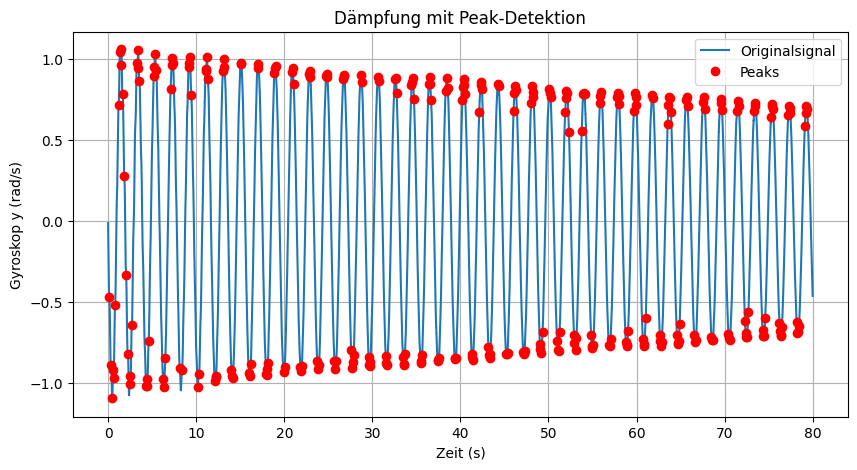

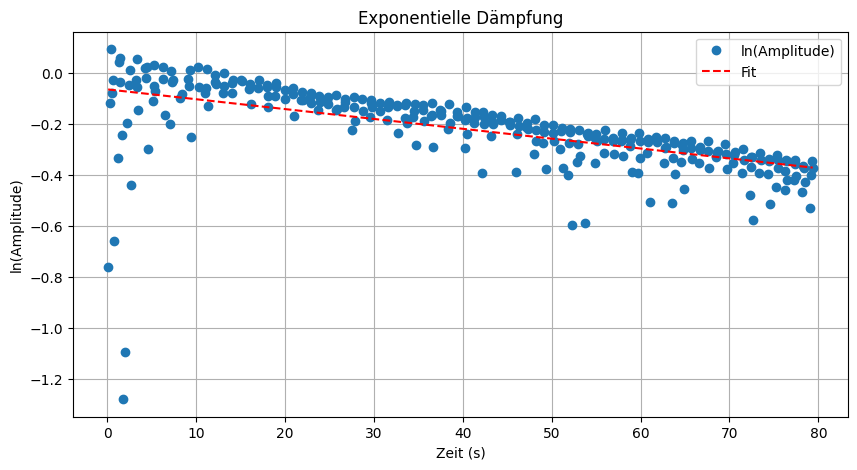

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

start_time = 20.3
end_time = 100.3

# CSV-Datei laden und Zeitfenster anwenden
df = pd.read_csv("data/Gyroscope.csv")
df = df[(df['Time (s)'] >= start_time) & (df['Time (s)'] <= end_time)]
df['Zeit_Angepasst'] = df['Time (s)'] - start_time

t = df['Zeit_Angepasst']
y = df['Gyroscope y (rad/s)']

# Peaks finden
peaks, _ = find_peaks(y, distance=30)
t_peaks = t.iloc[peaks]
y_peaks = y.iloc[peaks]

# Logarithmus der Amplituden
log_amplituden = np.log(np.abs(y_peaks))

# Fit-Funktion
def linear(t, a, delta):
    return a - delta * t

# Curve-Fit anwenden
params, _ = curve_fit(linear, t_peaks, log_amplituden)
a_fit, delta = params

print(f"Dämpfungskonstante delta: {delta:.4f} 1/s")

# Plot: Originalsignal mit Peaks
plt.figure(figsize=(10, 5))
plt.plot(t, y, label="Originalsignal")
plt.plot(t_peaks, y_peaks, "ro", label="Peaks")
plt.xlabel("Zeit (s)")
plt.ylabel("Gyroskop y (rad/s)")
plt.legend()
plt.title("Dämpfung mit Peak-Detektion")
plt.grid()
plt.show()

# Plot: Logarithmus der Amplituden
plt.figure(figsize=(10, 5))
plt.plot(t_peaks, log_amplituden, "o", label="ln(Amplitude)")
plt.plot(t_peaks, linear(t_peaks, *params), "r--", label="Fit")
plt.xlabel("Zeit (s)")
plt.ylabel("ln(Amplitude)")
plt.title("Exponentielle Dämpfung")
plt.legend()
plt.grid()
plt.show()


# 5. Bestimmung der Komponenten der Beschleunigung

Um die einzelnen Komponenten der Beschleunigung zu berechnen, ist es wichtig zu wissen wo sich das Gyroskop genau befindet. Für den Versuch wurde ein Samsung S24 verwendet, doch da wir im Internet keinen genauen Bauplan des Geräts finden konnten, kann die genau Position nicht abgeschätzt werden. Deshalb nehemn wir für die Berechnung an, dass sich das Gyroskop genau mittig im Smartphone befindet. 

Zum berechnen der Beschleunigung nutzen wir die gegebene Formel aus der Aufgabe, zum einen mit g:
$$
\begin{aligned}
\overrightarrow{a}=\overrightarrow{g}+\overrightarrow{a_{zf}}+\overrightarrow{a_{\alpha}}=\overrightarrow{g}-\overrightarrow{\omega}\times (\overrightarrow{\omega}\times \overrightarrow{r})-\overrightarrow{\alpha}\times \overrightarrow{r}
\end{aligned}
$$

und ohne g:
$$
\begin{aligned}
\overrightarrow{a}=\overrightarrow{a_{zf}}+\overrightarrow{a_{\alpha}}=-\overrightarrow{\omega}\times (\overrightarrow{\omega}\times \overrightarrow{r})-\overrightarrow{\alpha}\times \overrightarrow{r}
\end{aligned}
$$

Daraus folgt, dass wir nun die Vektoren für $\overrightarrow{r}$, $\overrightarrow{\omega}$ und $\overrightarrow{\alpha}$ aufstellen müssen um die Berechnung durchzuführen. Das Smartphone schwingt mit einem Abstand von $l=0.93cm$ und dieses Seil verläuft entlang der negativen Z-Achse. Daraus folgt:
$$
\begin{aligned}
\overrightarrow{r}=
\begin{pmatrix}
0\\
0\\
-l
\end{pmatrix}
\end{aligned}
$$
Bei der Schwinung dreht sich das Smartphone um die Y-Achse, weshalb für $\overrightarrow{\omega}$ und $\overrightarrow{\alpha}$ gilt:
$$
\begin{aligned}
\overrightarrow{\alpha}=
\begin{pmatrix}
0\\
\alpha\\
0
\end{pmatrix}
\\
\overrightarrow{\omega}=
\begin{pmatrix}
0\\
\omega\\
0
\end{pmatrix}
\end{aligned}
$$
Für die Gravitation g erhält man:
$$
\begin{aligned}
\overrightarrow{g}=
\begin{pmatrix}
g\cdot sin(\varphi)\\
0\\
-g \cdot cos(\varphi)
\end{pmatrix}
\end{aligned}
$$
Wenn man nun alles in die Formel für die Beschleunigung mit g ($\overrightarrow{a_{g}}$) und ohne g ($\overrightarrow{a}$)einsetzt erhält man:
$$
\begin{aligned}
\overrightarrow{a_{g}}=
\begin{pmatrix}
g \cdot sin(\varphi) + l \cdot \alpha\\
0\\
-g \cdot cos(\varphi) - l \cdot \omega^2
\end{pmatrix}
\\
\overrightarrow{a}=
\begin{pmatrix}
l \cdot \alpha\\
0\\
-l \cdot \omega^2
\end{pmatrix}
\end{aligned}
$$
Jetzt fehlen nur noch die Formeln für $\varphi$, $\omega$ und $\alpha$. Da wir $\varphi$ aus dem Aufgabenblatt entnehmen, können wir die anderen beiden jeweils durch zeitliche Ableitung von $\varphi$ bilden.
$$
\begin{aligned}
\varphi = \varphi_{0}cos(\omega_{0}t + \beta) \\
\omega = \dot{\varphi} = - \varphi_{0} f_{0}2\pi sin(f_{0}2\pi t) \\
\alpha = \ddot{\varphi} = - \varphi_{0} f_{0}^2 4\pi^2 cos(f_{0}2\pi t) \\

\end{aligned}
$$

Als erstes berechnen wir die Beschleunigung ohne g und erstellen jeweils einen Plot um die gemessenen Geschwindigkeitkomponenten jeder Achse mit den theoretischen zu vergleichen. Die Beschleunigung ohne g ist einfach die lineare Beschleunigung wie sie oben gezeigt wurde.

Die Pendellänge ist wie oben beschrieben $l=0.93 cm$, die Frequenz hatten wir auch oben bestimmt mit $f = 0.5169 Hz$ und die Anfangsauslenkung unseres Pendels lag bei ca. $15 \degree$.


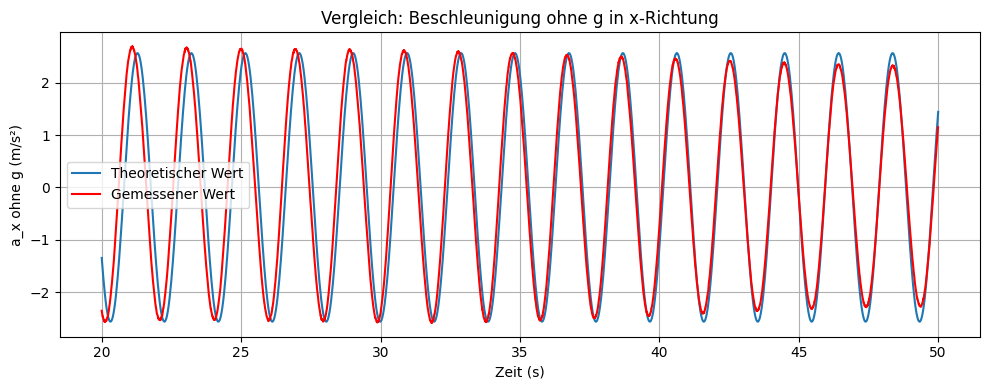

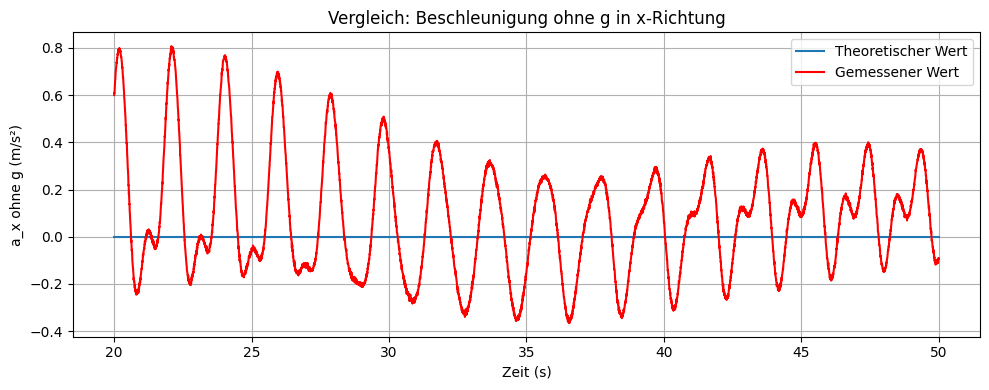

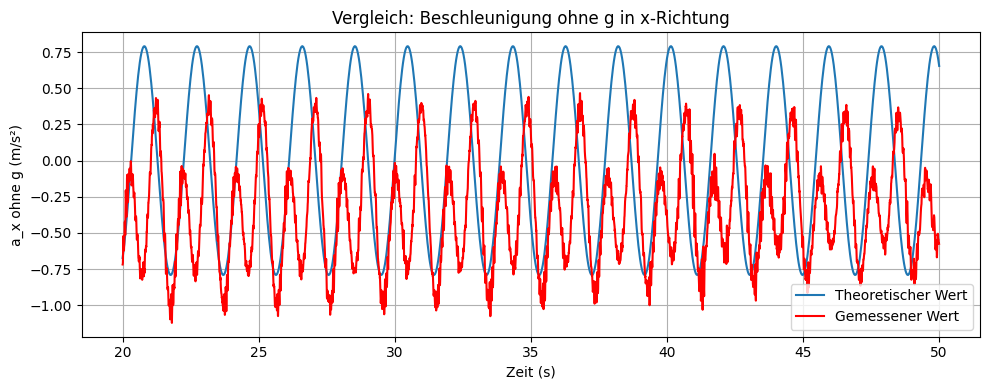

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('data/Linear Acceleration.csv')


# Filtere Daten im Bereich 20s bis 50s
df_filtered = df[(df['Time (s)'] >= 20) & (df['Time (s)'] <= 50)]



frequency = 0.5169
omega = 2 * np.pi * frequency
phi0 = 0.2618
l = 0.93

# Neue Zeitachse für theoretische Kurve im Bereich 20-50s
time_theo = np.linspace(20, 50, 1000)
a_x_theo = l * phi0 * omega**2 * np.cos(omega * time_theo)
a_y_theo = 0 * time_theo
a_z_theo = - l * phi0 * frequency * 2 * np.pi * np.sin(frequency * 2 * np.pi * time_theo)

# Plot für a_x
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_x_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered['Linear Acceleration x (m/s^2)'], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x ohne g (m/s²)")
plt.title("Vergleich: Beschleunigung ohne g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot für a_y
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_y_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered['Linear Acceleration y (m/s^2)'], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x ohne g (m/s²)")
plt.title("Vergleich: Beschleunigung ohne g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot für a_z
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_z_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered['Linear Acceleration z (m/s^2)'], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x ohne g (m/s²)")
plt.title("Vergleich: Beschleunigung ohne g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



Jetzt betrachten wir noch die Beschleunigungskomponenten mit g.

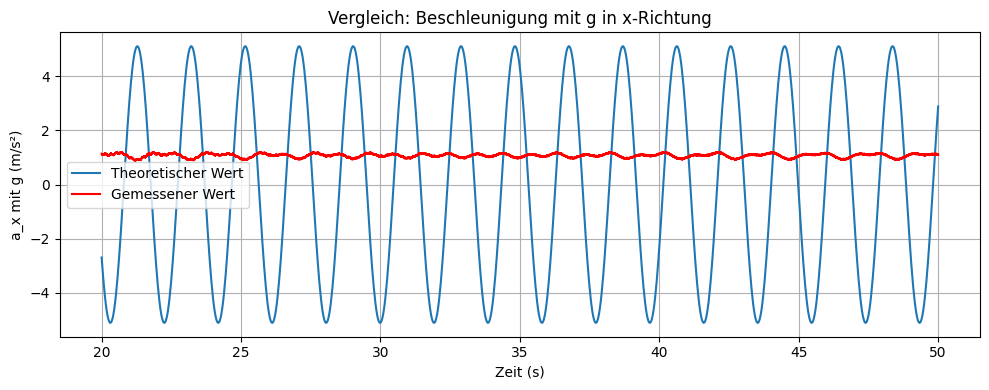

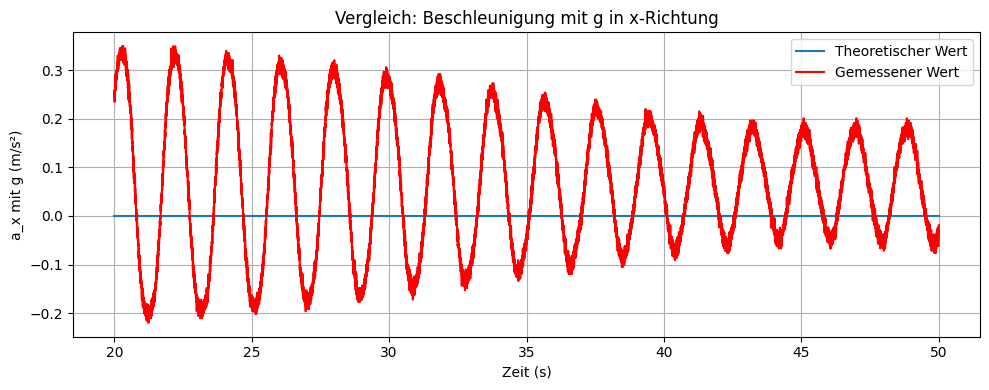

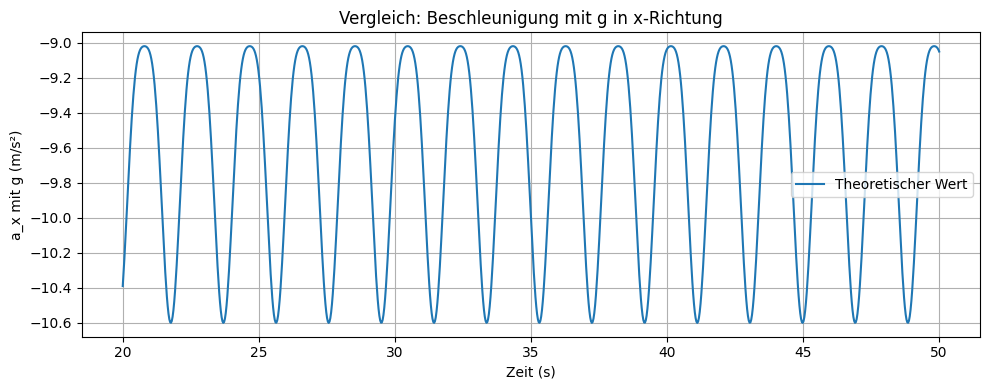

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('data/Accelerometer.csv')


# Filtere Daten im Bereich 20s bis 50s
df_filtered = df[(df['Time (s)'] >= 20) & (df['Time (s)'] <= 50)]

# Neue Zeitachse für theoretische Kurve im Bereich 20-50s
time_theo = np.linspace(20, 50, 1000)

g = 9.81
frequency = 0.5169
omega = 2 * np.pi * frequency
phi0 = 0.2618
l = 0.93
phi = phi0 * np.cos(omega * time_theo)



a_x_theo = g * np.sin(phi) + l * phi0 * omega**2 * np.cos(omega * time_theo)
a_y_theo = 0 * time_theo
a_z_theo = -g * np.cos(phi) - l * phi0 * frequency * 2 * np.pi * np.sin(frequency * 2 * np.pi * time_theo)

# Plot für a_x
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_x_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered["Acceleration x (m/s^2)"], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x mit g (m/s²)")
plt.title("Vergleich: Beschleunigung mit g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot für a_y
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_y_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered["Acceleration y (m/s^2)"], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x mit g (m/s²)")
plt.title("Vergleich: Beschleunigung mit g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot für a_z
plt.figure(figsize=(10, 4))
plt.plot(time_theo, a_z_theo, label="Theoretischer Wert")
plt.plot(df_filtered['Time (s)'], df_filtered["Acceleration z (m/s^2)"], label="Gemessener Wert", color='r')
plt.xlabel("Zeit (s)")
plt.ylabel("a_x mit g (m/s²)")
plt.title("Vergleich: Beschleunigung mit g in x-Richtung")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# 6. Fazit
Zusammenfassend lässt sich sagen, dass die Durchführung des Versuchs erfolgreich war und die Ergebnisse den theoretischen Erwartungen entsprachen, trotz der anfänglichen Schwierigkeiten des Versuchsaufaufbaus um das rotieren und somit auch das rauschen inden Messdaten zu minimieren, was am Ende auch erfolgreich gelungen ist. Die Frequenz des Pendels wurde mit verschiedenen Methoden bestimmt, wobei alle Ergebnisse nur eine sehr geringe Messabweichung hatten. Die Dämpfungskonstante konnte ebenfalls ermittelt werden, was auf eine gute Qualität der Messdaten hinweist. Die Analyse der Beschleunigungs- und Gyroskopdaten lieferte wertvolle Einblicke in das Verhalten des Pendels und bestätigten die Theorie.